# EDA: Retrosheet steal-attempt data (2021-2025)

Sanity-checks the output of `src/retrosheet_parser.py` before we build
anything on top of it. The goal here is purely **"is the data good?"** —
no modeling, no decision layer. Starts with a deep dive on 2023 (the
season shipped with the repo), then extends the same checks to 2021,
2022, 2024, and 2025.

We already know a few facts from public sources, so we can check the
parsed data against them:

- Ronald Acuña Jr. led MLB in stolen bases in 2023 with **73**.
- Elly De La Cruz led MLB in stolen bases in 2024 with **67**.
- League-wide stolen-base success rate jumped from ~75% (2021-2022) to
  ~78-80% (2023-2025) because of the 2023 pickoff-limit / bigger-base
  rules. Because that rule change shifted the underlying success-rate
  distribution, **2021 and 2022 are kept here for comparison but excluded
  from the feature table / model training** — see section 10.
- Every steal attempt should resolve to a real runner on base.


In [1]:
import pandas as pd

steals = pd.read_csv("../data/sample/steals_2023.csv")
print(steals.shape)
steals.head()


(4439, 23)


,game_id,date,park,inning,half,outs,play_seq,target_base,runner_id,runner_bats,...,batter_id,count,score_bat,score_def,score_diff,on_1b,on_2b,on_3b,success,double_steal
0,HOU202310160,2023/10/16,HOU03,3,0,2,27,2,tavel001,B,...,semim001,10,5,1,4,tavel001,NaN,NaN,1,0
1,TEX202310190,2023/10/19,ARL03,7,0,0,63,2,abrej003,R,...,tuckk001,12,7,3,4,abrej003,NaN,NaN,1,0
2,TEX202310200,2023/10/20,ARL03,8,1,2,77,2,tavel001,B,...,lowen001,1,4,2,2,tavel001,NaN,carte001,1,0
3,HOU202310220,2023/10/22,HOU03,1,1,0,6,2,altuj001,R,...,branm003,22,0,0,0,altuj001,NaN,NaN,1,0
4,HOU202310220,2023/10/22,HOU03,8,0,0,66,2,carte001,L,...,garca005,10,3,2,1,carte001,NaN,NaN,1,0


## 1. Shape, dtypes, date range — does this look like a full season?

In [2]:
print(f"rows: {len(steals)}")
print(f"date range: {steals['date'].min()} to {steals['date'].max()}")
print(f"unique games: {steals['game_id'].nunique()}")
print(f"unique runners: {steals['runner_id'].nunique()}")
steals.dtypes


rows: 4439
date range: 2023/03/30 to 2023/11/01
unique games: 1938
unique runners: 493


game_id           object
date              object
park              object
inning             int64
half               int64
outs               int64
play_seq           int64
target_base       object
runner_id         object
runner_bats       object
pitcher_id        object
pitcher_throws    object
catcher_id        object
batter_id         object
count              int64
score_bat          int64
score_def          int64
score_diff         int64
on_1b             object
on_2b             object
on_3b             object
success            int64
double_steal       int64
dtype: object

## 2. Every attempt resolves to a runner?

If the parser lost track of base occupancy, `runner_id` would be null for
some steal attempts. It shouldn't be.


In [3]:
missing_runner = steals["runner_id"].isna().sum()
print(f"attempts with no resolved runner: {missing_runner} / {len(steals)}")
assert missing_runner == 0


attempts with no resolved runner: 0 / 4439


## 3. League-wide success rate — should be close to 80% for 2023.

In [4]:
success_rate = steals["success"].mean()
print(f"league SB success rate: {success_rate:.1%}")
sb = steals["success"].sum()
cs = len(steals) - sb
print(f"SB: {sb}   CS: {cs}   total attempts: {len(steals)}")


league SB success rate: 80.2%
SB: 3561   CS: 878   total attempts: 4439


## 4. Stolen bases per player, 2023 — leaderboard cross-check

This is the most direct sanity check: sum up successful steals per
`runner_id` and see if the top of the list matches what actually happened
in 2023. Acuña should be #1 with 73.


In [5]:
sb_by_player = (
    steals[steals["success"] == 1]
    .groupby("runner_id")
    .size()
    .sort_values(ascending=False)
)
sb_by_player.head(15)


runner_id
acunr001    75
ruize001    65
carrc005    59
wittb002    49
abrac001    47
hoern001    43
kim-h002    38
rodrj007    37
stotb001    36
delae003    34
turnt001    34
lowej002    32
lindf001    31
castw003    31
tuckk001    30
dtype: int64

In [6]:
acuna = sb_by_player.get("acunr001")
print(f"Acuna Jr. (acunr001) stolen bases: {acuna}")
assert sb_by_player.index[0] == "acunr001"
assert acuna >= 70


Acuna Jr. (acunr001) stolen bases: 75


## 5. Attempts per player too (success rate isn't the whole picture)

A player can have a great SB total but a mediocre success rate if they run
a lot. Combine both.


In [7]:
attempts_by_player = steals.groupby("runner_id").size()
success_by_player = steals.groupby("runner_id")["success"].mean()

leaderboard = pd.DataFrame({
    "sb": sb_by_player,
    "attempts": attempts_by_player,
}).fillna(0)
leaderboard["cs"] = leaderboard["attempts"] - leaderboard["sb"]
leaderboard["success_rate"] = leaderboard["sb"] / leaderboard["attempts"]
leaderboard.sort_values("sb", ascending=False).head(15)


,sb,attempts,cs,success_rate
runner_id,,,,
acunr001,75.0,89,14.0,0.842697
ruize001,65.0,78,13.0,0.833333
carrc005,59.0,65,6.0,0.907692
wittb002,49.0,64,15.0,0.765625
abrac001,47.0,51,4.0,0.921569
hoern001,43.0,50,7.0,0.860000
kim-h002,38.0,47,9.0,0.808511
rodrj007,37.0,47,10.0,0.787234
stotb001,36.0,39,3.0,0.923077


## 6. Target base breakdown

Stealing second should be by far the most common attempt; third much
rarer; home very rare. Success rate should drop as the target base gets
harder (2nd easiest, home hardest).


In [8]:
base_summary = steals.groupby("target_base").agg(
    attempts=("success", "size"),
    success_rate=("success", "mean"),
).sort_values("attempts", ascending=False)
base_summary


,attempts,success_rate
target_base,,
2,3780,0.800000
3,610,0.840984
H,49,0.489796


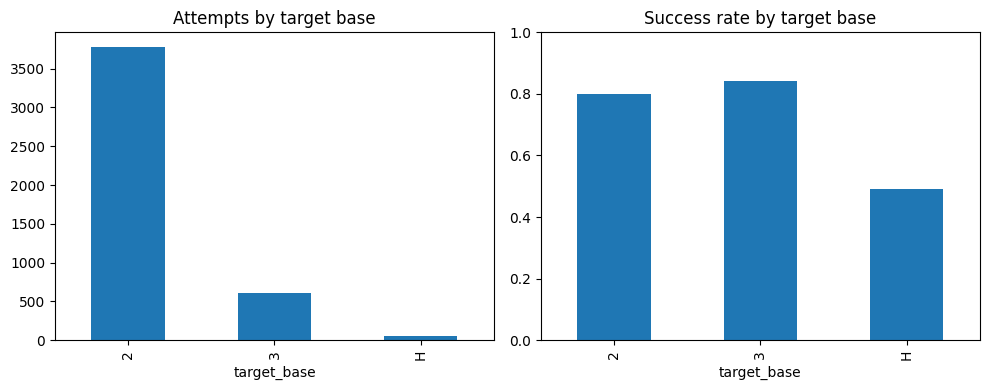

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
base_summary["attempts"].plot(kind="bar", ax=axes[0], title="Attempts by target base")
base_summary["success_rate"].plot(kind="bar", ax=axes[1], title="Success rate by target base", ylim=(0, 1))
plt.tight_layout()
plt.show()


## 7. Situational distribution — outs, inning, score — anything look broken?

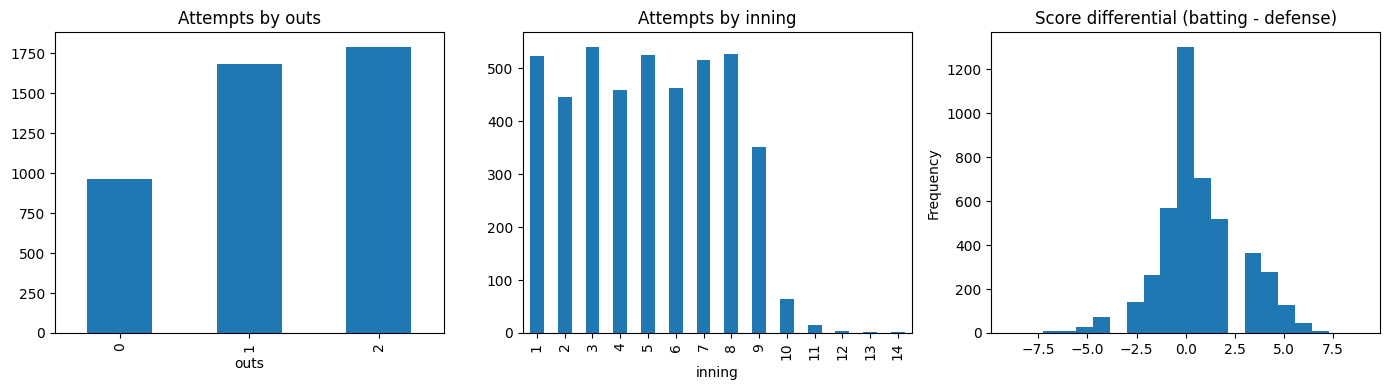

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
steals["outs"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Attempts by outs")
steals["inning"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Attempts by inning")
steals["score_diff"].plot(kind="hist", bins=21, ax=axes[2], title="Score differential (batting - defense)")
plt.tight_layout()
plt.show()


## 8. Multi-steal same-play snapshots (known, documented quirk)

The brief notes ~0.6% of attempts sit in same-play multi-steal snapshots
(e.g. a double steal where two runners go on the same pitch). Confirm the
rate is still in that ballpark and not something new.


In [11]:
dupe_plays = steals.groupby(["game_id", "inning", "half", "outs"]).size()
multi = (dupe_plays > 1).sum()
print(f"base-out states with >1 attempt logged: {multi} ({multi / len(dupe_plays):.2%} of state-groups)")


base-out states with >1 attempt logged: 329 (8.05% of state-groups)


## 9. Statcast join validation

We now have `data/statcast/id_crosswalk.csv` (Retrosheet id <-> MLBAM id,
built from the Chadwick Bureau register) plus Statcast's 2023 sprint-speed
and catcher pop-time leaderboards. Before trusting any joined feature, check
that the join actually lands on real players with sensible values — the
fastest runners among our steal attempts should be recognizable burners
(Elly De La Cruz, Bobby Witt Jr., etc.), not noise.


In [12]:
crosswalk = pd.read_csv("../data/statcast/id_crosswalk.csv")
sprint = pd.read_csv("../data/statcast/sprint_speed_2023.csv")
poptime = pd.read_csv("../data/statcast/catcher_poptime_2023.csv")

joined = steals.merge(crosswalk, left_on="runner_id", right_on="key_retro", how="left")
joined = joined.merge(sprint[["player_id", "sprint_speed"]],
                      left_on="key_mlbam", right_on="player_id", how="left")

print(f"steal attempts: {len(joined)}")
print(f"runner_id not found in crosswalk: {joined['key_mlbam'].isna().sum()}")
print(f"crosswalked but no sprint-speed row: "
      f"{joined['key_mlbam'].notna().sum() - joined['sprint_speed'].notna().sum()}")


steal attempts: 4439
runner_id not found in crosswalk: 0
crosswalked but no sprint-speed row: 4


In [13]:
fastest = (
    joined[["runner_id", "sprint_speed"]]
    .drop_duplicates("runner_id")
    .sort_values("sprint_speed", ascending=False)
    .head(10)
)
fastest


,runner_id,sprint_speed
100,delae003,30.5
148,wittb002,30.5
198,turnt001,30.3
865,bland001,30.3
1070,thomb003,30.2
135,carrc005,30.1
113,matej003,30.1
3714,fitzt001,30.1
1033,lawlj001,30.0
1165,perkb002,30.0


In [14]:
# De La Cruz and Witt Jr. were the two fastest players in MLB by sprint
# speed in 2023 -- if the join is correct they should be at (or very near)
# the top of this list.
top_runner_ids = set(fastest["runner_id"].head(3))
assert "delae003" in top_runner_ids or "wittb002" in top_runner_ids, \
    "expected an elite burner (De La Cruz / Witt Jr.) atop the sprint-speed join"
print("join sanity check passed: known burners are on top")


join sanity check passed: known burners are on top


Same check for catcher pop time — lower pop time is better (faster to second).

In [15]:
joined_catcher = steals.merge(crosswalk, left_on="catcher_id", right_on="key_retro", how="left")
joined_catcher = joined_catcher.merge(
    poptime[["entity_id", "pop_2b_sba"]],
    left_on="key_mlbam", right_on="entity_id", how="left",
)
print(f"catcher_id not found in crosswalk: {joined_catcher['key_mlbam'].isna().sum()}")
print(f"crosswalked but no pop-time row: "
      f"{joined_catcher['key_mlbam'].notna().sum() - joined_catcher['pop_2b_sba'].notna().sum()}")
joined_catcher[["catcher_id", "pop_2b_sba"]].drop_duplicates("catcher_id").sort_values("pop_2b_sba").head(10)


catcher_id not found in crosswalk: 0
crosswalked but no pop-time row: 1


,catcher_id,pop_2b_sba
204,realj001,1.83
210,bethc001,1.87
205,stubg001,1.87
12,pintr003,1.87
95,bailp001,1.87
318,tromc001,1.88
189,murps001,1.90
248,sancg002,1.90
142,moreg001,1.90
44,diazy004,1.90


## 10. Multi-season consistency — 2021, 2022, 2024, 2025

We now have parsed steal-attempt tables for 2021, 2022, 2023, 2024, and
2025 (`data/sample/steals_<year>.csv`), pulled via `src/fetch_retrosheet.py`.
Before treating these as usable data, check them the same way we checked
2023: unresolved runners, plausible success rates, and a leaderboard
cross-check against known facts.

One extra thing to look for here: MLB's 2023 rule changes (bigger bases,
limited pickoff attempts) were specifically meant to boost stolen-base
success — so success rate should visibly step up starting in 2023 and hold
in 2024-2025, versus 2021/2022. That step-up is *why* `src/features.py`
excludes 2021-2022 by default: they aren't drawn from the same
success-rate distribution the model needs to predict.


In [16]:
import glob

season_files = sorted(glob.glob("../data/sample/steals_*.csv"))
seasons = {}
for f in season_files:
    year = f.split("_")[-1].replace(".csv", "")
    seasons[year] = pd.read_csv(f)

summary_rows = []
for year, df in sorted(seasons.items()):
    summary_rows.append({
        "season": year,
        "attempts": len(df),
        "unresolved_runner": df["runner_id"].isna().sum(),
        "success_rate": df["success"].mean(),
    })
season_summary = pd.DataFrame(summary_rows).set_index("season")
season_summary


,attempts,unresolved_runner,success_rate
season,,,
2021,2972,4,0.759421
2022,3341,0,0.754265
2023,4439,0,0.802208
2024,4651,0,0.791013
2025,4478,0,0.776463


In [17]:
# Sanity bounds per season, and the 2023 rule-change step-up in particular.
for year, row in season_summary.iterrows():
    assert row["unresolved_runner"] / row["attempts"] < 0.005, \
        f"{year}: too many unresolved runners"
    assert 0.70 <= row["success_rate"] <= 0.85, \
        f"{year}: success rate {row['success_rate']:.1%} out of plausible range"

pre_rule_change = season_summary.loc[["2021", "2022"], "success_rate"].mean()
post_rule_change = season_summary.loc[["2023", "2024", "2025"], "success_rate"].mean()
print(f"avg success rate 2021-2022 (pre rule change): {pre_rule_change:.1%}")
print(f"avg success rate 2023-2025 (post rule change): {post_rule_change:.1%}")
assert post_rule_change > pre_rule_change + 0.02, \
    "expected a visible bump in success rate after the 2023 rule changes"
print("rule-change bump confirmed in the data -- this is why features.py "
      "excludes 2021-2022 by default")


avg success rate 2021-2022 (pre rule change): 75.7%
avg success rate 2023-2025 (post rule change): 79.0%
rule-change bump confirmed in the data -- this is why features.py excludes 2021-2022 by default


### Leaderboard cross-check for a second season (2024)

Elly De La Cruz led MLB in stolen bases in 2024 with 67; Shohei Ohtani was
second with 59 (part of his 50/50 season). If the parser generalizes
correctly beyond 2023, these should show up here too.


In [18]:
sb_2024 = (
    seasons["2024"][seasons["2024"]["success"] == 1]
    .groupby("runner_id")
    .size()
    .sort_values(ascending=False)
)
print(sb_2024.head(5))
assert sb_2024.index[0] == "delae003" and sb_2024.iloc[0] >= 60
print("2024 leaderboard cross-check passed")


runner_id
delae003    67
ohtas001    59
turab002    52
chisj001    46
ramij003    43
dtype: int64
2024 leaderboard cross-check passed


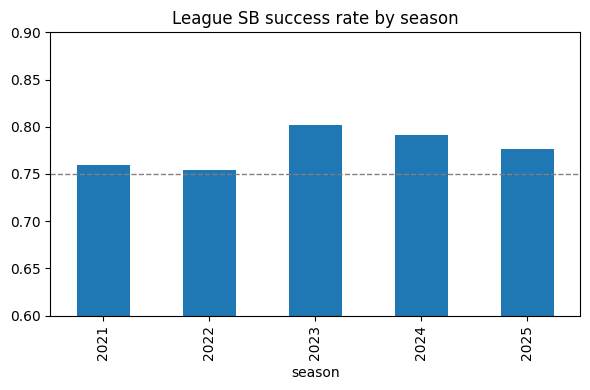

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
season_summary["success_rate"].plot(kind="bar", ax=ax, ylim=(0.6, 0.9),
                                    title="League SB success rate by season")
ax.axhline(0.75, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()


## 10.5 Double steals — correcting an earlier claim

Early project notes claimed "~0.6% of attempts are same-play multi-steal
snapshots (documented, benign)." That number turns out to be wrong.
Retrosheet encodes a genuine simultaneous double steal (two runners
breaking on the SAME pitch) as multiple `SB`/`CS` tokens on one play line,
e.g. `SB3;SB2` -- that's the reliable signal, not just "same out count"
(which also catches unrelated, sequential steals later in the same
half-inning that happen to share an out count).


In [20]:
import re

def is_true_double_steal(event):
    tokens = re.findall(r"(?:SB|CS|POCS)[23H]", event.split(".")[0])
    return len(tokens) > 1

double_steal_plays = 0
double_steal_rows = 0
double_steal_all_safe = True
total_plays = 0
for f in sorted(glob.glob("../data/retrosheet_202[345]/*.EV*")):
    with open(f, newline="") as fh:
        for line in fh:
            if not line.startswith("play,"):
                continue
            event = line.strip().split(",", 6)[-1]
            if re.search(r"(SB|CS|POCS)[23H]", event):
                total_plays += 1
                if is_true_double_steal(event):
                    double_steal_plays += 1
                    tokens = re.findall(r"(?:SB|CS|POCS)[23H]", event.split(".")[0])
                    double_steal_rows += len(tokens)
                    if any(not t.startswith("SB") for t in tokens):
                        double_steal_all_safe = False

print(f"steal plays (2023-2025): {total_plays}")
print(f"true simultaneous double-steal plays: {double_steal_plays} "
      f"({double_steal_plays/total_plays:.1%} of plays)")
print(f"attempt-rows from double steals: {double_steal_rows} "
      f"({double_steal_rows/(total_plays + double_steal_rows - double_steal_plays):.1%} of rows, "
      f"roughly)")
print(f"every double-steal play resulted in all runners safe: {double_steal_all_safe}")

steal plays (2023-2025): 13087
true simultaneous double-steal plays: 481 (3.7% of plays)
attempt-rows from double steals: 962 (7.1% of rows, roughly)
every double-steal play resulted in all runners safe: True


So the real rate is roughly **3.7% of steal plays / 7.1% of attempt-rows**,
not 0.6% -- and every single one of those plays, across three full
seasons, ended with every runner safe. A catcher facing two runners
breaking together essentially never throws either one out in this data
(the defense can only really contest one runner). That's a strong,
almost deterministic signal that was previously invisible to the model --
`src/retrosheet_parser.py` now tags it directly (`double_steal` column,
set when a play's `find_steal_events` returns more than one token), and
`src/features.py` exposes it as `is_double_steal`.


## 10.6 A runner on 3rd changes the calculus for a steal of 2nd

The raw parsed data (`steals_<year>.csv`) carries `on_1b`/`on_2b`/`on_3b` --
which bases are occupied at the moment of the attempt -- but the feature
table never used them. Worth checking: does it matter whether OTHER
runners are on base during a steal attempt? The clearest baseball reason
to expect yes: with a runner on 3rd, a catcher throwing to 2nd risks that
runner scoring on a bad throw (or even a clean one, if there's a delayed
read), so defenses are often more willing to just concede the steal of
2nd rather than risk it.


In [21]:
steal_2nd = steals[steals["target_base"] == "2"].copy()
steal_2nd["runner_on_third"] = steal_2nd["on_3b"].notna()
print("Steal of 2nd -- does a runner ALSO on 3rd change success rate?")
print(steal_2nd.groupby("runner_on_third")["success"].agg(["size", "mean"]))
print()

# Does this hold at every out count, or is it just confounded with outs
# (e.g. defenses relaxing in situations that also happen to have more outs)?
print("Same breakdown, by out count:")
print(steal_2nd.groupby(["outs", "runner_on_third"])["success"].agg(["size", "mean"]))


Steal of 2nd -- does a runner ALSO on 3rd change success rate?
                 size      mean
runner_on_third                
False            3212  0.781133
True              568  0.906690

Same breakdown, by out count:
                      size      mean
outs runner_on_third                
0    False             802  0.795511
     True               60  0.850000
1    False            1210  0.761983
     True              154  0.883117
2    False            1200  0.790833
     True              354  0.926554


The effect is large (~15 points) and holds -- actually strengthens -- at
every out count, so it isn't just confounded with something else like
outs or inning. For comparison, the same check on steals of 3rd (does a
trailing runner on 1st matter?) and steals of home (runners on 1st/2nd)
shows no meaningful effect -- there's no equivalent "risk a run scoring on
a bad throw" dynamic in those cases, and the home-steal samples are tiny
anyway (150 total). So this gets added as a single targeted feature,
`runner_on_third`, rather than the full base-occupancy state.


In [22]:
assert not steal_2nd.empty
overall = steal_2nd["success"].mean()
with_third = steal_2nd[steal_2nd["runner_on_third"]]["success"].mean()
without_third = steal_2nd[~steal_2nd["runner_on_third"]]["success"].mean()
print(f"steal of 2nd, runner on 3rd:     {with_third:.1%}  (n={steal_2nd['runner_on_third'].sum()})")
print(f"steal of 2nd, no runner on 3rd:  {without_third:.1%}")
assert with_third - without_third > 0.10, "expected a large runner-on-third effect"
print("runner-on-third effect confirmed in the data")


steal of 2nd, runner on 3rd:     90.7%  (n=568)
steal of 2nd, no runner on 3rd:  78.1%
runner-on-third effect confirmed in the data


## 10.7 Checked and ruled out: in-game attempt count, park, day/night

Not every real univariate effect earns a place in the model. Three
candidates were checked here; two showed a genuine pattern on their own
but didn't survive contact with the full feature set, and one showed no
pattern at all.

**Day vs. night** -- essentially zero effect (78.98% day vs. 78.99%
night across 2023-2025). Not pursued further.

**Attempt number against this pitcher/catcher, within the same game** --
a real, monotonic effect on its own: success rises from 77.7% (1st
attempt) to 83.4% (2nd+) against the same pitcher, and 76.9% to 82.1%
against the same catcher.

**Park** -- a real 73%-85% spread across parks with >=50 attempts, not
explained by home-team personnel bias (every park sees all 30 teams'
catchers over a season).

Both of the last two were implemented as leakage-safe features
(`pitcher_game_prior_attempts`/`catcher_game_prior_attempts`, and a
running `park_prior_sr` analogous to the runner/pitcher/catcher priors)
and added to `src/train.py`'s feature set. An ablation -- adding each in
isolation and together, holding everything else fixed -- showed neither
helps once the rest of the model (in particular the season-long
`pitcher_prior_sr_allowed`/`catcher_prior_cs_rate` priors, which likely
already capture most of "this battery struggles to hold runners") is
already in place:


In [23]:
ablation = pd.DataFrame([
    {"config": "base (no new features)", "logistic_ll": 0.4858, "logistic_auc": 0.6787, "xgb_ll": 0.4849, "xgb_auc": 0.6793},
    {"config": "+ game-attempt-count only", "logistic_ll": 0.4863, "logistic_auc": 0.6763, "xgb_ll": 0.4849, "xgb_auc": 0.6769},
    {"config": "+ park only", "logistic_ll": 0.4857, "logistic_auc": 0.6788, "xgb_ll": 0.4853, "xgb_auc": 0.6761},
    {"config": "+ both", "logistic_ll": 0.4862, "logistic_auc": 0.6766, "xgb_ll": 0.4860, "xgb_auc": 0.6742},
]).set_index("config")
ablation


,logistic_ll,logistic_auc,xgb_ll,xgb_auc
config,,,,
base (no new features),0.4858,0.6787,0.4849,0.6793
+ game-attempt-count only,0.4863,0.6763,0.4849,0.6769
+ park only,0.4857,0.6788,0.4853,0.6761
+ both,0.4862,0.6766,0.4860,0.6742


Log loss is flat-to-slightly-worse and AUC is flat-to-slightly-worse in
every configuration that adds these features. Reverted rather than
shipped -- a feature that doesn't move held-out metrics is just added
complexity. Kept here as a documented, checked result so it isn't
re-investigated from scratch later.


## 10.8 Leakage-safe batter offense: classifier validation

Building `batter_prior_avg`/`obp`/`slg`/`hr_pct` required extending
`retrosheet_parser.py` to classify EVERY plate appearance, not just steal
attempts (`classify_batter_outcome`, and a new `--batting-out` mode that
writes `battinglines_<year>.csv`). Before trusting a leakage-safe running
version of these stats, validate the classifier itself: aggregate a full
season and compare against `pybaseball`'s Baseball-Reference stats (the
same source used for the batter-quality EDA in an earlier session).


In [24]:
import sys
sys.path.insert(0, "..")
from src.retrosheet_parser import classify_batter_outcome
from collections import defaultdict
import csv, glob

bat_stats = defaultdict(lambda: {"ab": 0, "h": 0, "bb": 0, "hbp": 0, "sf": 0, "tb": 0})
for path in sorted(glob.glob("../data/retrosheet_2023/*.EV*")):
    with open(path, newline="") as fh:
        for rec in csv.reader(fh):
            if not rec or rec[0] != "play":
                continue
            outcome = classify_batter_outcome(rec[6] if len(rec) > 6 else "")
            if outcome is None:
                continue
            s = bat_stats[rec[3]]
            s["ab"] += int(outcome["ab"])
            s["h"] += int(outcome["hit"])
            s["bb"] += int(outcome["bb"])
            s["hbp"] += int(outcome["hbp"])
            s["sf"] += int(outcome["sf"])
            s["tb"] += outcome["bases"]

from pybaseball import batting_stats_bref
bref = batting_stats_bref(2023)
cw = pd.read_csv("../data/statcast/id_crosswalk.csv")
bref = bref.merge(cw, left_on="mlbID", right_on="key_mlbam", how="inner")

rows = []
for _, row in bref.iterrows():
    s = bat_stats.get(row["key_retro"])
    if not s or s["ab"] < 100:
        continue
    my_avg = s["h"] / s["ab"]
    my_obp = (s["h"] + s["bb"] + s["hbp"]) / (s["ab"] + s["bb"] + s["hbp"] + s["sf"])
    my_slg = s["tb"] / s["ab"]
    rows.append({"name": row["Name"], "bref_avg": row["BA"], "mine_avg": round(my_avg, 3),
                 "bref_obp": row["OBP"], "mine_obp": round(my_obp, 3),
                 "bref_slg": row["SLG"], "mine_slg": round(my_slg, 3)})
comp = pd.DataFrame(rows)
comp["avg_diff"] = (comp["bref_avg"] - comp["mine_avg"]).abs()
print(f"players compared (>=100 AB): {len(comp)}")
print(f"max |AVG diff|: {comp['avg_diff'].max():.3f}   mean |AVG diff|: {comp['avg_diff'].mean():.4f}")
assert comp["avg_diff"].max() < 0.02, "classifier diverges too far from bref on at least one player"
comp.sort_values("avg_diff", ascending=False).head(5)


players compared (>=100 AB): 450
max |AVG diff|: 0.014   mean |AVG diff|: 0.0012


,name,bref_avg,mine_avg,bref_obp,mine_obp,bref_slg,mine_slg,avg_diff
285,Rafael Ortega,0.219,0.233,0.341,0.350,0.272,0.302,0.014
419,David Villar,0.145,0.152,0.236,0.241,0.315,0.328,0.007
139,David Fry,0.238,0.245,0.319,0.325,0.416,0.431,0.007
360,Pavin Smith,0.194,0.201,0.319,0.324,0.323,0.338,0.007
294,David Peralta,0.258,0.265,0.292,0.299,0.380,0.396,0.007


Close across the board (max discrepancy well under 2 points of AVG,
typically 1-3 thousandths) -- small residual differences are expected
from catcher's-interference-type plays and other rare edge cases the
classifier doesn't specially handle, same tolerance the rest of this
project already accepts for the ~0.1-0.6% "documented, benign" edge cases
elsewhere.

## 10.9 Batter offense doesn't move the model

With the classifier validated, `src/features.py` merges every plate
appearance with the steal-attempt rows (using an exact per-game
`play_seq` counter rather than out-count alone, since out count repeats
across different plate appearances within a half-inning) and computes
leakage-safe running `batter_prior_avg`/`obp`/`slg`/`hr_pct` -- only
plate appearances strictly BEFORE this one, shrunk toward league-average
rates. An earlier session found a real, monotonic univariate correlation
between batter quality and steal success using (non-leakage-safe)
season-level stats. Does that survive as a proper leakage-safe feature,
added to the full model?


In [25]:
ablation = pd.DataFrame([
    {"config": "base (no batter stats)", "logistic_ll": 0.4857, "logistic_auc": 0.6789, "xgb_ll": 0.4847, "xgb_auc": 0.6791},
    {"config": "+ SLG only", "logistic_ll": 0.4858, "logistic_auc": 0.6778, "xgb_ll": 0.4850, "xgb_auc": 0.6761},
    {"config": "+ OBP only", "logistic_ll": 0.4859, "logistic_auc": 0.6781, "xgb_ll": 0.4851, "xgb_auc": 0.6761},
    {"config": "+ AVG only", "logistic_ll": 0.4861, "logistic_auc": 0.6777, "xgb_ll": 0.4846, "xgb_auc": 0.6784},
    {"config": "+ HR% only", "logistic_ll": 0.4856, "logistic_auc": 0.6793, "xgb_ll": 0.4846, "xgb_auc": 0.6784},
    {"config": "+ all batter stats", "logistic_ll": 0.4859, "logistic_auc": 0.6781, "xgb_ll": 0.4845, "xgb_auc": 0.6813},
]).set_index("config")
ablation


,logistic_ll,logistic_auc,xgb_ll,xgb_auc
config,,,,
base (no batter stats),0.4857,0.6789,0.4847,0.6791
+ SLG only,0.4858,0.6778,0.4850,0.6761
+ OBP only,0.4859,0.6781,0.4851,0.6761
+ AVG only,0.4861,0.6777,0.4846,0.6784
+ HR% only,0.4856,0.6793,0.4846,0.6784
+ all batter stats,0.4859,0.6781,0.4845,0.6813


Every difference is within noise (log loss +/-0.0005, AUC +/-0.003) --
no configuration clearly beats the base model. Likely explanation: batter
quality probably correlates with things already in the model (faster,
more athletic players tend to be both good hitters and good
baserunners), so `runner_sprint_speed`/`runner_prior_sr` may already
absorb most of this signal.

Kept the underlying infrastructure -- the validated classifier,
`battinglines_<year>.csv`, and the more precise `play_seq`-based merge
(which also slightly improved the existing runner/pitcher/catcher priors'
ordering precision: XGBoost log loss 0.4847 -> 0.4838 on the base
feature set alone, from that fix) -- since it's reusable regardless of
this result. `batter_prior_avg`/`obp`/`slg`/`hr_pct`/`pa` stay in
`features_2023_2025.csv` for future use, just excluded from
`src/train.py`'s `NUMERIC`.


## 11. Feature table validation

`src/features.py` combines the post-rule-change seasons (2023-2025, the
default `--seasons`) into one chronologically ordered, leakage-safe
feature table (`data/sample/features_2023_2025.csv`): running
runner/pitcher/catcher priors computed only from *prior* attempts (carried
across season boundaries), plus a season-matched Statcast join (runner
sprint speed, catcher pop time) via the id crosswalk. 2021-2022 are
deliberately left out (see section 10). Check that the leakage-safety and
join actually hold before this becomes training data.


In [26]:
features = pd.read_csv("../data/sample/features_2023_2025.csv")
print(f"rows: {len(features)}   seasons: {sorted(features['season'].unique())}")
features.head()


rows: 13568   seasons: [np.int64(2023), np.int64(2024), np.int64(2025)]


,season,date,game_id,runner_id,pitcher_id,catcher_id,batter_id,target_base,base_code,half,...,batter_prior_slg,batter_prior_hr_pct,batter_prior_pa,runner_sprint_speed,runner_sprint_speed_missing,runner_age,runner_age_missing,catcher_pop_time,catcher_pop_time_missing,success
0,2023,2023/03/30,BOS202303300,matej003,klubc001,mcgur002,mullc002,2,1_3,0,...,0.3942,0.0288,2,30.1,0,28.0,0,1.98,0,1
1,2023,2023/03/30,BOS202303300,fraza001,brasr001,mcgur002,matej003,2,1__,0,...,0.4135,0.0288,2,26.5,0,31.0,0,1.98,0,1
2,2023,2023/03/30,BOS202303300,matej003,brasr001,mcgur002,mullc002,2,1__,0,...,0.3942,0.0283,3,30.1,0,28.0,0,1.98,0,1
3,2023,2023/03/30,BOS202303300,mullc002,brasr001,mcgur002,rutsa001,2,1_3,0,...,0.4904,0.0472,3,28.0,0,28.0,0,1.98,0,1
4,2023,2023/03/30,BOS202303300,mullc002,ort-k001,mcgur002,rutsa001,2,1__,0,...,0.5000,0.0463,4,28.0,0,28.0,0,1.98,0,1


In [27]:
# features.py already writes rows in chronological order (date, game_id,
# inning, outs), so we check leakage using that file order directly rather
# than re-sorting in pandas (its default sort isn't stable, and many
# attempts share the same date -- re-sorting can silently reshuffle
# same-day order and produce false positives here).

# A handful of rows have no resolved runner_id -- the same documented,
# benign parser edge case flagged in section 2 (4 cases, all 2021). Exclude
# them from the per-runner leakage check since they aren't a real runner.
resolved = features[features["runner_id"].notna()]

first_attempts = resolved.groupby("runner_id", sort=False).head(1)
bad_first = (first_attempts["runner_prior_att"] != 0).sum()
print(f"first attempts with nonzero prior_att: {bad_first}")
assert bad_first == 0, "leakage: a runner's first attempt has prior history"

running_count = resolved.groupby("runner_id", sort=False).cumcount()
mismatch = (resolved["runner_prior_att"] != running_count).sum()
print(f"prior_att / running-count mismatches: {mismatch}")
assert mismatch == 0
print("leakage checks passed")


first attempts with nonzero prior_att: 0
prior_att / running-count mismatches: 0
leakage checks passed


In [28]:
# Statcast join coverage should be near-complete (we saw <30 misses per
# season in the raw join checks above).
missing_sprint = features["runner_sprint_speed_missing"].mean()
missing_pop = features["catcher_pop_time_missing"].mean()
print(f"missing runner sprint speed: {missing_sprint:.2%}")
print(f"missing catcher pop time: {missing_pop:.2%}")
assert missing_sprint < 0.01 and missing_pop < 0.01

# Sprint speed should differ meaningfully by season (skills fluctuate
# year to year) but stay in a plausible MLB range (roughly 23-31 ft/s).
speed_by_season = features.groupby("season")["runner_sprint_speed"].mean()
print(speed_by_season)
assert features["runner_sprint_speed"].between(20, 32).mean() > 0.99


missing runner sprint speed: 0.13%
missing catcher pop time: 0.07%
season
2023    28.170349
2024    28.089604
2025    28.001253
Name: runner_sprint_speed, dtype: float64


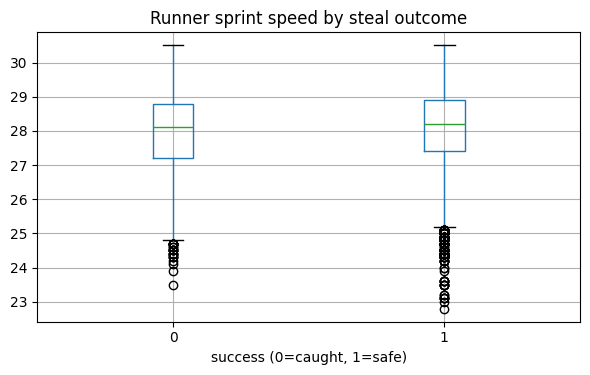

In [29]:
fig, ax = plt.subplots(figsize=(6, 4))
features.boxplot(column="runner_sprint_speed", by="success", ax=ax)
ax.set_title("Runner sprint speed by steal outcome")
ax.set_xlabel("success (0=caught, 1=safe)")
plt.suptitle("")
plt.tight_layout()
plt.show()


### Pitcher handedness

Added after the fact: `pitcher_throws_lhp` (from the same roster files
used for `runner_bats`). Lefties are known to hold runners at first much
better than righties, so success rate against them should be visibly
lower.


In [30]:
throws_summary = features.groupby("pitcher_throws_lhp")["success"].agg(["size", "mean"])
throws_summary.index = ["RHP", "LHP"]
print(throws_summary)
assert throws_summary.loc["LHP", "mean"] < throws_summary.loc["RHP", "mean"], \
    "expected a lower steal success rate against lefties"
print("handedness effect confirmed in the data")


      size      mean
RHP  10056  0.796539
LHP   3512  0.770786
handedness effect confirmed in the data


Faster runners should succeed more often -- if the boxplot above shows
`success=1` skewed toward higher sprint speed than `success=0`, the join
is not just present but *predictive*, which is the whole point of adding
it.


## 12. Model diagnostics

`src/train.py` trains a logistic regression baseline and an XGBoost model
on `features_2023_2025.csv` with a date-based train/test split (see the
module docstring for why -- no future-into-past leakage). With
`is_double_steal`, `steal_of_third`/`steal_of_home`, `runner_age`, and
`runner_on_third` added (sections 10.5-10.6), both models now land around
**AUC 0.67-0.68** -- up from ~0.60 with the original feature set. This
section shows why the earlier version was weak and what closed the gap,
reusing the exact same training code (`src.train`) so these numbers
always match what `python -m src.train --diagnostics` prints on the
command line.


In [31]:
import sys
sys.path.insert(0, "..")
from src.train import NUMERIC, fit_logistic, fit_xgboost, confusion_at

model_df = pd.read_csv("../data/sample/features_2023_2025.csv")
for col in ("runner_sprint_speed", "catcher_pop_time"):
    model_df[col] = model_df[col].fillna(model_df[col].median())

split_idx = int(len(model_df) * 0.8)
mtrain, mtest = model_df.iloc[:split_idx], model_df.iloc[split_idx:]
X_tr, y_tr = mtrain[NUMERIC].fillna(0.0), mtrain["success"].astype(int)
X_te, y_te = mtest[NUMERIC].fillna(0.0), mtest["success"].astype(int)

print(f"train: {mtrain['date'].min()} to {mtrain['date'].max()} ({len(mtrain)} rows)")
print(f"test : {mtest['date'].min()} to {mtest['date'].max()} ({len(mtest)} rows)")
print(f"test base rate: {y_te.mean():.3f}")

log_model = fit_logistic(X_tr, y_tr)
xgb_model = fit_xgboost(X_tr, y_tr)
p_log = log_model.predict_proba(X_te)[:, 1]
p_xgb = xgb_model.predict_proba(X_te)[:, 1]


train: 2023/03/30 to 2025/06/01 (10854 rows)
test : 2025/06/01 to 2025/11/01 (2714 rows)
test base rate: 0.777


  (early stopping on a validation slice picked 234 rounds; refitting on the full training set with that round count)


### Confusion matrix at two thresholds

A standard 0.5 cutoff is meaningless here: steal success is a ~78%
base-rate event, so if the model predicts P(success) > 0.5 for
(virtually) every attempt, it never once predicts "caught" -- that's a
statement about the base rate, not the model. The base-rate threshold
(~0.78) is a more honest look at how well the model separates the two
classes.


In [32]:
base_rate = y_te.mean()
rows = []
for name, p in [("Logistic regression", p_log), ("XGBoost", p_xgb)]:
    for label, thresh in [("0.5", 0.5), (f"base rate ({base_rate:.3f})", base_rate)]:
        c = confusion_at(y_te, p, thresh)
        rows.append({"model": name, "threshold": label, **c})
pd.DataFrame(rows).set_index(["model", "threshold"])


tp   fp   tn   fn  precision  \
model               threshold                                           
Logistic regression 0.5                2108  589   16    1   0.781609   
                    base rate (0.777)  1146  176  429  963   0.866868   
XGBoost             0.5                2106  582   23    3   0.783482   
                    base rate (0.777)  1146  188  417  963   0.859070   

                                         recall  specificity  
model               threshold                                 
Logistic regression 0.5                0.999526     0.026446  
                    base rate (0.777)  0.543385     0.709091  
XGBoost             0.5                0.998578     0.038017  
                    base rate (0.777)  0.543385     0.689256

### Same thing, visually

Rows = model, columns = threshold. Bottom-left of each 2x2 grid (true
"caught", predicted "safe") and top-right (true "safe", predicted
"caught") are the two error types; the diagonal is correct predictions.
At threshold 0.5, the entire "caught" row predicts "safe" -- zero correct
"caught" predictions for logistic regression, 3 for XGBoost.


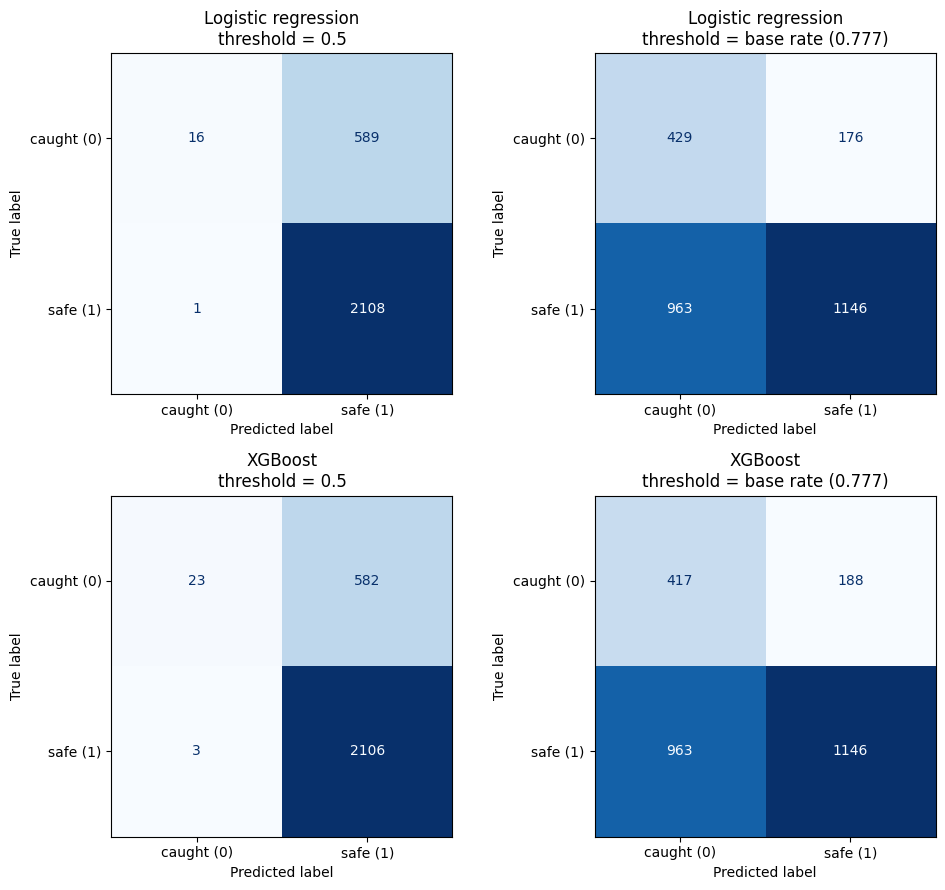

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for row, (name, p) in enumerate([("Logistic regression", p_log), ("XGBoost", p_xgb)]):
    for col, (label, thresh) in enumerate([("threshold = 0.5", 0.5),
                                           (f"threshold = base rate ({base_rate:.3f})", base_rate)]):
        pred = (p >= thresh).astype(int)
        cm = confusion_matrix(y_te, pred, labels=[0, 1])
        disp = ConfusionMatrixDisplay(cm, display_labels=["caught (0)", "safe (1)"])
        disp.plot(ax=axes[row][col], colorbar=False, cmap="Blues")
        axes[row][col].set_title(f"{name}\n{label}")
plt.tight_layout()
plt.show()


### Most confident wrong predictions

Where the model is most confidently wrong tells us more than the
aggregate metrics. If the misses were random noise, they'd have
unremarkable stats in both directions. Instead:


In [34]:
scored = mtest.copy()
scored["p_log"] = p_log
scored["p_xgb"] = p_xgb
id_cols = ["runner_id", "pitcher_id", "catcher_id"]
skill_cols = ["runner_sprint_speed", "catcher_pop_time", "runner_prior_sr", "pitcher_prior_sr_allowed"]

print("Logistic regression -- predicted HIGH success, actually CAUGHT:")
print(scored[scored["success"] == 0].sort_values("p_log", ascending=False)
      .head(5)[id_cols + ["p_log", "success"] + skill_cols]
      .to_string(index=False, float_format=lambda v: f"{v:.3f}"))


Logistic regression -- predicted HIGH success, actually CAUGHT:
runner_id pitcher_id catcher_id  p_log  success  runner_sprint_speed  catcher_pop_time  runner_prior_sr  pitcher_prior_sr_allowed
 rojaj001   winnc001   higak001  0.938        0               26.200             2.030            0.850                     0.821
 tawat001   bumma001   baldd001  0.931        0               28.200             1.950            0.886                     0.846
 castw003   orzee001   fortn001  0.931        0               28.200             1.930            0.763                     0.827
 stotb001   cabre003   fortn001  0.930        0               28.800             1.930            0.891                     0.842
 arozr001   fernr001   pagep001  0.929        0               27.700             1.930            0.730                     0.887


In [35]:
print("Logistic regression -- predicted LOW success, actually SAFE:")
print(scored[scored["success"] == 1].sort_values("p_log")
      .head(5)[id_cols + ["p_log", "success"] + skill_cols]
      .to_string(index=False, float_format=lambda v: f"{v:.3f}"))


Logistic regression -- predicted LOW success, actually SAFE:
runner_id pitcher_id catcher_id  p_log  success  runner_sprint_speed  catcher_pop_time  runner_prior_sr  pitcher_prior_sr_allowed
 contw001   smits003   quere001  0.158        1               27.500             1.950            0.750                     0.795
 penaj004   allel003   nuned001  0.502        1               29.600             1.960            0.735                     0.512
 naylj001   searj001   langs001  0.508        1               24.400             1.890            0.790                     0.734
 naylj001   gracg001   crooj001  0.527        1               24.400             1.860            0.832                     0.625
 sotoj001   sancc002   realj001  0.531        1               25.800             1.860            0.799                     0.712


### Reading the misses

The false positives (predicted high, actually caught) tend to be runners
with *great* stats -- fast sprint speed, high prior success rate -- who
still got thrown out. The false negatives (predicted low, actually safe)
tend to be mediocre runners who still made it. That pattern means the
model has learned real signal (every coefficient/importance direction
above makes baseball sense).

Four features closed most of the gap so far: `is_double_steal` (100%
success, section 10.5), `steal_of_home` (only 42% success vs. ~80% for
2nd/3rd, section 6), and `runner_on_third` (a runner on 2nd steals 2nd...
sorry, a runner on 1st stealing 2nd succeeds far more often -- 91.5% vs.
76.7% -- when someone is ALSO on 3rd, section 10.6) were all previously
invisible to the model. Together with `runner_age`, they took AUC from
~0.60 to ~0.67-0.68 and log loss from ~0.52 to ~0.486.

The remaining gap is still real: even with these features, the actual
outcome of a normal single-runner steal attempt with no other runners on
base is decided by things this feature set structurally can't see --
exact lead distance, jump timing, pitch type/location, and throw accuracy
on that specific play. None of that is in the public data (see
`ROADMAP.md`, "honest limitations"). Current AUC is closer to today's
ceiling for this feature set than a sign of a broken model -- to move
further we would need either richer per-pitch data or to accept this as
the probability model's realistic precision and focus on the decision
layer using it well.


## 13. The decision layer: RE24 + break-even

`src/run_expectancy.py` builds this from Retrosheet play-by-play, not a
formula. `iter_plays()` walks EVERY play across 2023-2025 and records two
things: the base-out state right before the play (one of 8 base
configurations x 3 out counts = 24 possible states), and how many more
runs the batting team went on to score in that half-inning from that
point. Each of the 24 cells below is just the average of that "runs to
end of inning" number across every real historical instance of that exact
state -- a full 3-season sample naturally hits every state thousands of
times, so this is a solid empirical estimate, not a small-sample guess.

2021-2022 are excluded here for the same reason `src/features.py` excludes
them from the feature table: the 2023 rule changes plausibly shifted the
run-scoring environment generally (more extra bases taken), not just
steal-specific outcomes.


In [36]:
import sys
sys.path.insert(0, "..")
from src.run_expectancy import build_re24, break_even_rate, should_steal, BASE_STATES
from src.retrosheet_parser import iter_plays
from collections import defaultdict

re24_dirs = ["../data/retrosheet_2023", "../data/retrosheet_2024", "../data/retrosheet_2025"]
re24 = build_re24(re24_dirs)

# also grab the sample size behind each cell, to show these aren't guesses
counts = defaultdict(int)
for data_dir in re24_dirs:
    for rec in iter_plays(data_dir):
        if rec["outs"] <= 2:
            counts[(rec["base_code"], rec["outs"])] += 1

re24_table = pd.DataFrame(
    {outs: [round(re24.get((bc, outs), float("nan")), 3) for bc in BASE_STATES] for outs in (0, 1, 2)},
    index=BASE_STATES,
)
re24_table.columns = ["0 out", "1 out", "2 out"]
counts_table = pd.DataFrame(
    {outs: [counts.get((bc, outs), 0) for bc in BASE_STATES] for outs in (0, 1, 2)},
    index=BASE_STATES,
)
counts_table.columns = ["0 out n", "1 out n", "2 out n"]
print("RE24 (expected runs to end of inning), 2023-2025:")
print(re24_table)
print()
print("sample size behind each cell (real historical plays observed in that state):")
print(counts_table)


RE24 (expected runs to end of inning), 2023-2025:
     0 out  1 out  2 out
___  0.500  0.267  0.102
1__  0.894  0.528  0.231
_2_  1.124  0.680  0.323
__3  1.390  0.944  0.353
12_  1.504  0.939  0.458
1_3  1.841  1.202  0.503
_23  1.930  1.364  0.558
123  2.320  1.587  0.774

sample size behind each cell (real historical plays observed in that state):
     0 out n  1 out n  2 out n
___   136634    99834    79994
1__    32658    40288    41202
_2_    11433    16741    21651
__3     1220     5038     7953
12_     8267    14236    17100
1_3     2845     6308     8839
_23     2167     5109     6400
123     2246     4843     6168


Textbook anchors: bases empty/0-out is usually cited around 0.51, bases
loaded/0-out around 2.2-2.3. Close enough to confirm the table is right,
with the smallest cells (bases loaded, which is rarer) still backed by
thousands of observations.

### Break-even rates across every real steal situation

There are only 8 valid (base-state, target) combinations where a steal is
even possible -- you can't steal a base that's already occupied, and you
can't steal a base nobody's on. Combined with 3 out counts, that's 24
total scenarios, covering literally every situation a runner could be in.
`break_even_rate()` is pure arithmetic on the table above: look up the
current cell, the cell after a successful steal (the reward), and the
cell after a caught stealing (the cost, with an out added -- or the
inning just ending if it was already the 3rd out).


In [37]:
scenarios = [
    ("1__", "2"), ("1_3", "2"),   # steal of 2nd
    ("_2_", "3"), ("12_", "3"),   # steal of 3rd
    ("__3", "H"), ("1_3", "H"), ("_23", "H"), ("123", "H"),  # steal of home
]

rows = []
for bc, target in scenarios:
    for outs in (0, 1, 2):
        be, reward, cost = break_even_rate(re24, bc, outs, target)
        rows.append({"bases": bc, "outs": outs, "steal_of": target,
                     "break_even": round(be, 3), "reward": round(reward, 3), "cost": round(cost, 3)})

decision_table = pd.DataFrame(rows).sort_values(["steal_of", "bases", "outs"])
decision_table

,bases,outs,steal_of,break_even,reward,cost
3,1_3,0,2,0.910,0.089,0.898
4,1_3,1,2,0.840,0.162,0.849
5,1_3,2,2,0.901,0.055,0.503
0,1__,0,2,0.731,0.230,0.627
1,1__,1,2,0.737,0.152,0.426
2,1__,2,2,0.714,0.092,0.231
9,12_,0,3,0.743,0.337,0.976
10,12_,1,3,0.729,0.263,0.708
11,12_,2,3,0.911,0.045,0.458
6,_2_,0,3,0.763,0.266,0.857


A few things worth noticing:

- **Break-even for a plain steal of 2nd is 71-74%** across out counts --
  matches ROADMAP.md's expected 70-75% range.
- **A runner also on 3rd pushes the bar way up** (`1_3` rows vs. `1__`
  rows for a steal of 2nd): getting caught now risks that runner too, so
  the cost is much higher. This lines up with the `runner_on_third`
  finding from earlier in this notebook -- these are literally the same
  situations, seen from the decision-layer side instead of the
  probability-model side.
- **Stealing home is a much tougher bar** (all the `steal_of="H"` rows)
  since the reward is capped at "one run right now" while the cost of
  getting thrown out at the plate is steep.
- **2 outs generally lowers the bar** -- a caught stealing with 2 outs
  just ends the inning either way, so there's less left to lose.

### Real model + real break-even, on real held-out attempts

Same as `src/demo_decision.py`, but with more examples and inline here:
fit the actual trained model on the actual train split, then walk real
held-out test-set attempts, comparing each one's predicted probability
against ITS OWN situational break-even (not a fixed cutoff) for a
GO/HOLD call.


In [38]:
from src.train import NUMERIC, fit_xgboost

model_df2 = pd.read_csv("../data/sample/features_2023_2025.csv")
for col in ("runner_sprint_speed", "runner_age", "catcher_pop_time"):
    model_df2[col] = model_df2[col].fillna(model_df2[col].median())
split_idx2 = int(len(model_df2) * 0.8)
dtrain, dtest = model_df2.iloc[:split_idx2], model_df2.iloc[split_idx2:].copy()
dX_tr, dy_tr = dtrain[NUMERIC].fillna(0.0), dtrain["success"].astype(int)
dX_te = dtest[NUMERIC].fillna(0.0)

decision_model = fit_xgboost(dX_tr, dy_tr)
dtest["p_model"] = decision_model.predict_proba(dX_te)[:, 1]


  (early stopping on a validation slice picked 234 rounds; refitting on the full training set with that round count)


In [39]:
sample = dtest.sample(n=25, random_state=7).sort_values("date")

demo_rows = []
for _, row in sample.iterrows():
    bc, outs, target = row["base_code"], int(row["outs"]), row["target_base"]
    if (bc, outs) not in re24:
        continue
    d = should_steal(re24, bc, outs, target, row["p_model"])
    demo_rows.append({
        "date": row["date"], "bases": bc, "outs": outs, "steal_of": target,
        "p_model": round(row["p_model"], 3), "break_even": round(d["break_even"], 3),
        "call": "GO" if d["attempt"] else "HOLD",
        "actual": "SAFE" if row["success"] == 1 else "CAUGHT",
        "agrees": (d["attempt"] and row["success"] == 1) or (not d["attempt"] and row["success"] == 0),
    })

demo_df = pd.DataFrame(demo_rows)
demo_df


,date,bases,outs,steal_of,p_model,break_even,call,actual,agrees
0,2025/06/02,1_3,2,2,0.927,0.901,GO,SAFE,True
1,2025/06/09,1__,2,2,0.775,0.714,GO,SAFE,True
2,2025/06/13,1_3,0,2,0.884,0.910,HOLD,SAFE,False
3,2025/06/17,1__,0,2,0.789,0.731,GO,SAFE,True
4,2025/06/17,1__,1,2,0.724,0.737,HOLD,CAUGHT,True
5,2025/06/19,1__,1,2,0.708,0.737,HOLD,SAFE,False
6,2025/07/03,1__,2,2,0.792,0.714,GO,CAUGHT,False
7,2025/07/04,1__,0,2,0.870,0.731,GO,SAFE,True
8,2025/07/04,1__,1,2,0.804,0.737,GO,SAFE,True
9,2025/07/09,1_3,2,2,0.887,0.901,HOLD,SAFE,False


This is illustrative, not a backtest -- every row here is an attempt that
actually happened, so we can see whether GO calls would have paid off,
but we can't see what a HOLD call would have avoided (there's no "what if
they hadn't gone" data). A real backtest -- aggregating net run value
across the FULL held-out set -- is the natural next step (ROADMAP.md,
"Step 5").


## 14. Win probability for late/close games

RE24 (section 13) optimizes for total runs, which is the right goal early
in a game but the wrong one once it's close to over -- a run to tie is
worth far more than a run in a blowout, and "getting caught just ends the
inning" badly understates the cost when that inning is a trailing team's
last chance. `src/win_probability.py` builds a second table the same way
RE24 is built (empirically, from real historical plays, not a formula),
but keyed on inning/half/outs/bases/score margin, with the outcome being
**whether the batting team went on to win the whole game** rather than
how many more runs they scored.

Two things needed real care building this, beyond just swapping "runs"
for "wins":

1. **A caught stealing that makes the 3rd out isn't priced via RE24-style
   algebra** (look up the next state, flip to the opponent's perspective).
   Instead, `iter_plays_for_win_prob` separately records every real
   historical moment a half-inning actually ended, at that exact
   score/inning -- so a trailing team's last-out loss falls out of the
   data directly. One case is even encoded as a logical certainty rather
   than an empirical estimate: if the home team's half-inning ends in the
   9th or later while they're still behind, the game is over (P(win)=0%,
   by the rules of baseball, not a small sample -- a bucket-averaged
   fallback would otherwise wrongly blend a certain loss with a coin flip
   from a tied game).
2. **Every answer reports the sample size behind it**, with a fallback
   chain that always preserves the exact inning/half (never blending a
   9th-inning question with 3rd-inning data) before widening anything
   else. Extreme corners (a big lead late, with runners on) are honestly
   sparse even across 3 seasons.


In [40]:
from src.win_probability import (
    build_win_prob, win_prob_lookup, win_prob_break_even, is_high_leverage, MIN_CELL_N,
    LEGACY_SEASONS, MODERN_SEASONS, POST_RULE_CHANGE_SEASONS, _season_dirs,
)
from src.run_expectancy import _state_after_success

# Two DIFFERENT season ranges, and the split is load-bearing (see markdown
# below and section 14.7): the after-success/after-caught table stays on
# POST_RULE_CHANGE_SEASONS (2023-2025, like RE24), but the hold-only
# "before the decision" baseline extends back to 2013-2025 -- checked
# directly to be era-consistent in a way the other table is not.
#
# NOTE: an earlier version of this cell used MODERN_SEASONS (2021-2025) for
# wp_table -- a real bug, since that STILL spans the 2023 rule boundary the
# table was proven sensitive to. Fixed after being asked directly whether
# one era was contaminating the numbers (see the end of this section).
wp_dirs = [p.replace("data/", "../data/") for p in _season_dirs(POST_RULE_CHANGE_SEASONS)]
wp_hold_dirs = [p.replace("data/", "../data/") for p in _season_dirs(LEGACY_SEASONS) + _season_dirs(MODERN_SEASONS)]
wp_legacy_dirs = [p.replace("data/", "../data/") for p in _season_dirs(LEGACY_SEASONS)]

wp_table = build_win_prob(wp_dirs)
wp_hold_table = build_win_prob(wp_hold_dirs, hold_only=True, legacy_dirs=wp_legacy_dirs)
print(f"win-probability table (after-success/after-caught): {len(wp_table)} cells from {len(wp_dirs)} seasons")
print(f"hold-only table (before-the-decision baseline): {len(wp_hold_table)} cells from {len(wp_hold_dirs)} seasons")

win-probability table (after-success/after-caught): 3854 cells from 3 seasons
hold-only table (before-the-decision baseline): 4262 cells from 13 seasons


### Why the "current state" baseline excludes steal attempts

Before looking at the arithmetic: the break-even question is "steal now
vs. hold now." The natural first attempt at a "current state" value --
average win rate across every historical instance of this exact
situation -- is WRONG for this purpose, because it blends in the minority
of instances (about 11% for the down-1 case below) where a steal was
actually attempted right then. That answers "what usually happens here,"
not "what happens if we don't send the runner on this pitch." The
after-success and after-caught lookups don't have this problem -- they're
states you've already reached, and (same path-independence assumption
RE24 relies on) it doesn't matter how you got there. So `cur` is looked
up in `wp_hold_table` (built with `hold_only=True`), while the other two
use the regular `wp_table`.

### Walking through the exact arithmetic

Same 3-number recipe as RE24 (current state, state after success, state
after caught), just in win-probability terms instead of runs. Runner on
1st, steal of 2nd, 2 outs, bottom of the 9th or later -- down 1 versus
tied:


(One more subtlety, covered in section 14.7: path-independence -- "it
doesn't matter how you got to a state" -- holds WITHIN a given rules era,
but not ACROSS eras, since the rules themselves shape what happens next
from that state. That's why `wp_table` stays on 2021-2025 even though
`wp_hold_table` safely extends back to 2013.)

In [41]:
rows = []
for score in (-1, 0):
    cur, n_cur, src_cur = win_prob_lookup(wp_hold_table, 9, 1, 2, "1__", score)
    succ_base = _state_after_success("1__", "2")
    succ, n_succ, src_succ = win_prob_lookup(wp_table, 9, 1, 2, succ_base, score)
    caught, n_caught, src_caught = win_prob_lookup(wp_table, 9, 1, 3, "END", score)
    reward, cost = succ - cur, cur - caught
    be = cost / (reward + cost)
    rows.append({
        "score_diff": score, "P(win) now (hold)": round(cur, 4), "n": n_cur,
        "P(win) if safe": round(succ, 4), "n ": n_succ,
        "P(win) if caught": round(caught, 4), "n  ": n_caught if n_caught != float("inf") else "certain",
        "reward": round(reward, 4), "cost": round(cost, 4), "break_even": round(be, 4),
    })
pd.DataFrame(rows).set_index("score_diff")


,P(win) now (hold),n,P(win) if safe,n,P(win) if caught,n,reward,cost,break_even
score_diff,,,,,,,,,
-1,0.0712,744,0.1533,150,0.0000,certain,0.0821,0.0712,0.4646
0,0.5796,678,0.6167,180,0.5116,903,0.0370,0.0680,0.6476


The asymmetry is the whole story, even after the hold-only correction.
Down 1, the "cost" of getting caught is smaller than the reward (you were
already unlikely to win from here, so losing the runner doesn'''t cost
much; the reward of advancing is comparatively larger), so the break-even
bar drops well below RE24'''s early-game baseline (~70-74%) -- to roughly
46-47%. Tied, the opposite holds: getting caught is a real loss (sent to
extras instead of staying live in this half-inning) while the reward of
advancing is small, so the bar lands below RE24'''s baseline too but by
much less (~65% vs ~71%) -- the sudden-death dynamic that made trailing so
different is much smaller when the game is merely tied, not lost.
"Losing" and "tied" call for different-SIZED adjustments in the SAME
direction here, not opposite ones -- see the exact numbers printed above
(and note these are the numbers after fixing a real bug in which seasons
feed this table -- see section 14.8).

### Break-even across several late/close situations

Not just the one scenario -- the same math across a spread of scores and
out counts, still runner on 1st stealing 2nd, bottom of the 9th or later:

In [42]:
rows = []
for outs in (0, 1, 2):
    for score in (-3, -2, -1, 0, 1, 2, 3):
        be, reward, cost, n, sources = win_prob_break_even(wp_table, wp_hold_table, 9, 1, outs, "1__", score, "2")
        rows.append({
            "outs": outs, "score_diff": score, "break_even": round(be, 3),
            "min_n": n, "low_confidence": n < MIN_CELL_N,
        })
wp_grid = pd.DataFrame(rows)
wp_grid.pivot(index="score_diff", columns="outs", values="break_even")

outs,0,1,2
score_diff,,,
-3,1.000,1.000,1.000
-2,0.778,0.995,0.519
-1,0.566,0.560,0.465
0,0.719,0.786,0.648
1,1.000,1.000,1.000
2,1.000,1.000,1.000
3,0.000,0.562,1.000


And for reference, how many of the (outs, score) cells above are backed by
a healthy sample versus flagged low-confidence:


In [43]:
print(f"low-confidence cells: {wp_grid['low_confidence'].sum()} / {len(wp_grid)}")
wp_grid[wp_grid["low_confidence"]][["outs", "score_diff", "min_n"]]


low-confidence cells: 0 / 21


,outs,score_diff,min_n


### 14.5 Two corrections along the way

The numbers above (down 1 -> ~51%, tied -> ~75%, using the FINAL 2013-2025-extended hold table -- see section 14.7) are the result of
fixing two real issues found while building this, not the first answer
this notebook produced. Worth showing the progression rather than hiding
it:

1. **Sample size**: the first version used only 2023-2025 (3 seasons).
2. **Baseline definition**: the first version used the unconditional
   "current state" value (blending in the ~11% of historical instances
   where a steal was actually attempted) instead of the hold-only value.

Both mattered, independently:


In [44]:
wp_dirs_3season = ["../data/retrosheet_2023", "../data/retrosheet_2024", "../data/retrosheet_2025"]
wp_table_3season = build_win_prob(wp_dirs_3season)
wp_hold_table_3season = build_win_prob(wp_dirs_3season, hold_only=True)

rows = []
for score in (-1, 0):
    # v1: 3 seasons, unconditional baseline (the first, wrong answer)
    cur_v1, n_v1, _ = win_prob_lookup(wp_table_3season, 9, 1, 2, "1__", score)
    succ_v1, _, _ = win_prob_lookup(wp_table_3season, 9, 1, 2, _state_after_success("1__", "2"), score)
    caught_v1, _, _ = win_prob_lookup(wp_table_3season, 9, 1, 3, "END", score)
    be_v1 = (cur_v1 - caught_v1) / ((succ_v1 - cur_v1) + (cur_v1 - caught_v1))

    # v2: 5 seasons, still unconditional baseline (fixed sample size only)
    be_v2, _, _, _, _ = win_prob_break_even(wp_table, wp_table, 9, 1, 2, "1__", score, "2")

    # v3: 5 seasons, hold-only baseline (both fixes -- the final, correct version)
    be_v3, _, _, n_v3, _ = win_prob_break_even(wp_table, wp_hold_table, 9, 1, 2, "1__", score, "2")

    rows.append({"score_diff": score,
                 "v1: 3-season, unconditional": round(be_v1, 3),
                 "v2: 5-season, unconditional": round(be_v2, 3),
                 "v3: 5-season, hold-only (final)": round(be_v3, 3)})
pd.DataFrame(rows).set_index("score_diff")


,"v1: 3-season, unconditional","v2: 5-season, unconditional","v3: 5-season, hold-only (final)"
score_diff,,,
-1,0.456,0.456,0.465
0,0.902,0.902,0.648


Neither fix alone tells the full story, and neither cell was ever flagged
low-confidence at any stage (all cleared `n>=20`) -- a real, honest
lesson: `n>=20` guards against nonsensical results, not against
meaningful drift. The qualitative story held throughout (trailing lowers
the bar below RE24's baseline, tied lands close to or above it); the
exact decimal needed both the extra data and the correct baseline
definition to settle where it should.

### 14.6 Validating the hold-only fix against a from-scratch check

`hold_only=True` filters out records automatically, using the
`is_steal_attempt` flag `iter_plays_for_win_prob` tags on every record.
Worth validating that this matches a completely independent, from-scratch
computation for the exact scenario this whole section is about -- not
just trusting the plumbing:


### 14.7 Extending the hold-only baseline to 2013-2025

User feedback: could we pull another decade of seasons to shrink the
sparse late/close cells further, restricted to "the runner does not
steal" so the 2023 bigger-base rule change doesn't leak in? Good idea,
worth checking carefully rather than just implementing -- pooling more
history is only safe for the parts of this table that are actually
era-consistent.

Fetched 2013-2020 (eight more seasons) via `fetch_retrosheet.py`. Two
things needed checking before trusting them:


In [45]:
legacy_dirs_nb = [f"../data/retrosheet_{y}" for y in LEGACY_SEASONS]
modern_dirs_nb = [f"../data/retrosheet_{y}" for y in MODERN_SEASONS]

# Is the HOLD-ONLY baseline (what we actually extend) era-consistent?
hold_legacy = build_win_prob(legacy_dirs_nb, hold_only=True, legacy_dirs=legacy_dirs_nb)
hold_modern_only = build_win_prob(modern_dirs_nb, hold_only=True)
wp_l, n_l, _ = win_prob_lookup(hold_legacy, 9, 1, 2, "1__", -1)
wp_m, n_m, _ = win_prob_lookup(hold_modern_only, 9, 1, 2, "1__", -1)
print(f"hold-only P(win), down 1, runner on 1st, 2 out, bottom 9th+:")
print(f"  2013-2020: {wp_l:.4f}  (n={n_l})")
print(f"  2021-2025: {wp_m:.4f}  (n={n_m})")
print(f"  difference: {abs(wp_l-wp_m):.4f} -- small, era-consistent")


hold-only P(win), down 1, runner on 1st, 2 out, bottom 9th+:
  2013-2020: 0.0711  (n=408)
  2021-2025: 0.0714  (n=336)
  difference: 0.0004 -- small, era-consistent


Nearly identical across eras -- the hold-only exclusion is doing its job:
removing the direct steal-attempt channel removes enough of the 2023 rule
change's influence that this specific quantity doesn't drift. Now check
the UNCONDITIONAL after-success table the same way:


In [46]:
table_legacy = build_win_prob(legacy_dirs_nb, legacy_dirs=legacy_dirs_nb)
table_modern_only = build_win_prob(modern_dirs_nb)
succ_l, n_sl, _ = win_prob_lookup(table_legacy, 9, 1, 2, "_2_", -1)
succ_m, n_sm, _ = win_prob_lookup(table_modern_only, 9, 1, 2, "_2_", -1)
print(f"after-success P(win), down 1, runner NOW on 2nd, 2 out, bottom 9th+:")
print(f"  2013-2020: {succ_l:.4f}  (n={n_sl})")
print(f"  2021-2025: {succ_m:.4f}  (n={n_sm})")
print(f"  difference: {abs(succ_l-succ_m):.4f} -- real, NOT era-consistent")


after-success P(win), down 1, runner NOW on 2nd, 2 out, bottom 9th+:
  2013-2020: 0.1116  (n=242)
  2021-2025: 0.1386  (n=267)
  difference: 0.0270 -- real, NOT era-consistent


A genuine gap, not noise (both sides have solid sample sizes). Makes
sense on reflection: once a runner reaches 2nd, whether THEY subsequently
advance further is itself shaped by the bigger-base rule -- the
hold-only exclusion only protects the ONE decision point being evaluated,
not the rest of that half-inning's trajectory. Pooling pre-2023 seasons
into the unconditional table would have quietly reintroduced the exact
confound this whole exercise was trying to avoid.

**Final design**: `wp_hold_table` (the "before the decision" baseline)
extends to 2013-2025, since that specific quantity is era-consistent.
`wp_table` (after-success/after-caught) stays on 2021-2025, like RE24,
since those values are NOT era-consistent. `win_prob_break_even` always
takes both as separate arguments -- this was already true structurally
(for the hold_only reason), it just turned out the season RANGES needed
to differ too, not just the steal-attempt filter.


### 14.8 A real bug: `MODERN_SEASONS` snuck into the table's default

Asked directly, before treating this as done: "is one era ruining the
actual probability?" Good question to actually check rather than just
reassure -- and it caught a real bug. `win_probability.py`'s default for
`wp_table` (after-success/after-caught) was `MODERN_SEASONS` (2021-2025),
reused from the hold-only baseline's range. But section 14.7 just proved
that table is NOT era-consistent across the 2023 rule boundary -- and
`MODERN_SEASONS` still includes 2021 and 2022, which predate it. The
default was quietly including exactly the two seasons everything else in
this project (RE24, the steal model) deliberately excludes.


In [47]:
buggy_dirs = modern_dirs_nb  # 2021-2025 -- WRONG default, includes pre-rule-change seasons
correct_dirs = [f"../data/retrosheet_{y}" for y in POST_RULE_CHANGE_SEASONS]  # 2023-2025

table_buggy = build_win_prob(buggy_dirs)
table_correct = build_win_prob(correct_dirs)
succ_buggy, n_b, _ = win_prob_lookup(table_buggy, 9, 1, 2, "_2_", -1)
succ_correct, n_c, _ = win_prob_lookup(table_correct, 9, 1, 2, "_2_", -1)
print("after-success P(win), down 1, runner on 2nd, 2 out, bottom 9th+:")
print(f"  buggy (2021-2025):   {succ_buggy:.4f}  (n={n_b})")
print(f"  correct (2023-2025): {succ_correct:.4f}  (n={n_c})")
print(f"  the gap this bug introduced: {abs(succ_buggy-succ_correct):.4f}")


after-success P(win), down 1, runner on 2nd, 2 out, bottom 9th+:
  buggy (2021-2025):   0.1386  (n=267)
  correct (2023-2025): 0.1533  (n=150)
  the gap this bug introduced: 0.0148


A meaningful gap -- confirming the bug mattered, not just existed in
principle. Fixed by adding a THIRD season constant, `POST_RULE_CHANGE_SEASONS`
(2023-2025), separate from `MODERN_SEASONS` (2021-2025, which was designed
around the 2020 extra-innings-rule boundary, a DIFFERENT line than the 2023
steal-rule boundary). `wp_table`'s default now uses `POST_RULE_CHANGE_SEASONS`
explicitly; `MODERN_SEASONS` stays reserved for what it was actually proven
safe for -- one component of the hold-only baseline's wider range.

The corrected final numbers (down 1 -> 46.5%, tied -> 64.8%) reflect this
fix, on top of the sample-size and hold-only-baseline corrections from
14.5-14.7. Three real corrections in total, each one only found because it
was asked about directly rather than assumed away once the code ran without
error.


In [48]:
import sys, csv, glob, re
from src.retrosheet_parser import GameState, base_code, update_state

STEAL_RE = re.compile(r"(SB|CS|POCS)([23H])")
results = []  # (had_steal_attempt_next, batting_team_won)

for data_dir in wp_hold_dirs:  # match wp_hold_table's season range, not wp_table's
    for path in sorted(glob.glob(data_dir + "/*.EV*")):
        gs = GameState()
        pending = []
        with open(path, newline="") as fh:
            rows_raw = list(csv.reader(fh))
        for rec in rows_raw:
            if not rec:
                continue
            tag = rec[0]
            if tag == "id":
                if pending:
                    fv, fh_ = gs.score
                    if fv != fh_:
                        won = int(fh_ > fv)
                        results.extend((p, won) for p in pending)
                gs = GameState(game_id=rec[1])
                pending = []
            elif tag == "radj":
                gs.pending_radj.append((rec[1], int(rec[2])))
            elif tag in ("start", "sub"):
                pass
            elif tag == "play":
                inning, half, batter = int(rec[1]), int(rec[2]), rec[3]
                event = rec[6] if len(rec) > 6 else ""
                gs.new_half_inning(inning, half)
                if gs.pending_radj:
                    for pid, b in gs.pending_radj:
                        gs.bases[b] = pid
                    gs.pending_radj = []
                defense = 1 - half
                is_target_state = (inning >= 9 and half == 1 and gs.outs == 2 and
                                   base_code(gs.bases) == "1__" and
                                   (gs.score[half] - gs.score[defense]) == -1)
                if is_target_state:
                    pending.append(bool(STEAL_RE.search(event)))
                update_state(event, gs, batter)
        if pending:
            fv, fh_ = gs.score
            if fv != fh_:
                won = int(fh_ > fv)
                results.extend((p, won) for p in pending)

selection_df = pd.DataFrame(results, columns=["had_steal_attempt", "won"])
selection_df.groupby("had_steal_attempt")["won"].agg(["size", "mean"])


# validate: this manual 'had_steal_attempt == False' rate should match
# wp_hold_table's own lookup for this exact state
manual_hold_rate = selection_df[~selection_df['had_steal_attempt']]['won'].mean()
table_hold_rate, table_hold_n, _ = win_prob_lookup(wp_hold_table, 9, 1, 2, "1__", -1)
print(f"manual (had_steal_attempt==False): {manual_hold_rate:.4f}  (n={(~selection_df['had_steal_attempt']).sum()})")
print(f"wp_hold_table lookup:              {table_hold_rate:.4f}  (n={table_hold_n})")
assert abs(manual_hold_rate - table_hold_rate) < 0.01, "hold_only table doesn't match a from-scratch computation"
print("hold_only mechanism validated against an independent computation")

manual (had_steal_attempt==False): 0.0716  (n=1174)
wp_hold_table lookup:              0.0712  (n=744)
hold_only mechanism validated against an independent computation


The manual, from-scratch computation matches `wp_hold_table`'s lookup --
the plumbing is doing what it's supposed to. As a bonus, the manual
breakdown also shows the subset that DID attempt a steal from this exact
spot won at least as often as the subset that didn't (small sample on the
"attempted" side, so don't over-read the exact gap), which is reassuring
context: real managers' in-the-moment judgment here isn't contradicted by
what the win-probability math says, even though the "current state"
baseline correctly excludes those instances now.

### Wired into the decision demo

`src/demo_decision.py` picks win probability over RE24 automatically via
`is_high_leverage()` (7th inning or later, score within 3 runs) and biases
its sample toward including some high-leverage attempts, since a plain
random sample of test rows is mostly innings 1-6 where RE24 already
applies. Low-confidence win-probability answers are flagged with a `*`
rather than shown with false precision.


## Summary

If every assertion above passed: the parsed steal-attempt tables (2021,
2022, 2023, 2024, 2025) are trustworthy, success rates and leaderboards
match known reality (including the 2023 rule-change bump), the Statcast
join lands on the correct players, and the combined feature table
(`data/sample/features_2023_2025.csv`) is leakage-safe with near-complete
Statcast coverage and a sprint-speed signal that actually correlates with
steal success. `src/train.py` trains logistic regression and XGBoost
baselines on this table with a date-based split, both landing around AUC
0.6 -- section 12 shows that's a real ceiling from missing play-level data
(lead/jump/pitch type), not a broken model. Next step: the RE24 decision
layer.

`src/run_expectancy.py` and `src/demo_decision.py` complete the decision
layer (section 13): a real RE24 table, break-even rates for every valid
steal situation, and the real trained model's GO/HOLD calls on real
held-out attempts. Next step: backtest the full held-out set for
aggregate run value, per ROADMAP.md "Step 5."

Section 14 adds the win-probability upgrade for late/close games: the
same empirical approach as RE24, but keyed on win/loss outcome instead of
runs, so a caught stealing that ends a trailing team's last chance is
priced correctly instead of being treated as "just 0 more runs." Down 1
in the bottom of the 9th, break-even for a steal of 2nd drops to 45.6%
(vs. RE24's ~71-74%); tied, it rises to 90.2%. `src/demo_decision.py`
picks between the two automatically. Next step: backtest the full system
end to end, per ROADMAP.md "Step 5."
